<a href="https://colab.research.google.com/github/abhishekCS0024/LangGraph/blob/main/STM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

In [2]:
!pip install langgraph-checkpoint-sqlite
!pip install langgraph-checkpoint-postgres

  Using cached langgraph_checkpoint_postgres-3.0.4-py3-none-any.whl.metadata (4.8 kB)
  Using cached psycopg_pool-3.3.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached psycopg-3.3.3-py3-none-any.whl.metadata (4.3 kB)
Using cached langgraph_checkpoint_postgres-3.0.4-py3-none-any.whl (42 kB)
Using cached psycopg-3.3.3-py3-none-any.whl (212 kB)
Using cached psycopg_pool-3.3.0-py3-none-any.whl (39 kB)


In [5]:
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.postgres import PostgresSaver

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode
import os

In [6]:
from langchain_groq import ChatGroq
from google.colab import userdata


llm=ChatGroq(
    temperature=0,
    groq_api_key=userdata.get('Groq'),
    model_name="qwen/qwen3-32b",
    verbose=True
)

In [7]:
# Create Agent State
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

In [8]:
"""
Centralized Tools Module
=========================

This module contains all reusable tools for LangGraph agents.
Import and use: import my_tools
"""

from langchain_core.tools import tool
import requests

# =============================================================================
# Weather Tools
# =============================================================================

@tool
def get_weather(location:str) -> str:
    """Get current weather for a location.

    Use for queries about weather, temperature, or conditions in any city.
    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"

    Args:
        location: City name (e.g., "New York", "London", "Tokyo")

    Returns:
        Current weather information including temperature and conditions.
    """

    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data



# =============================================================================
# Math Tools
# =============================================================================
@tool
def calculate(expression: str) -> str:
    """Calculate a mathematical expression.

    USE THIS TOOL FOR:
    - Any mathematical calculations or arithmetic operations
    - Queries involving numbers and operators (+, -, *, /, **, %)
    - Questions asking to compute, calculate, or solve math problems
    - Evaluating mathematical expressions

    EXAMPLE QUERIES:
    - "What is 2 + 2?"
    - "Calculate 15 times 7"
    - "Solve 100 / 4"
    - "What's 5 to the power of 3?"
    - "Compute 45 * 12 + 30"

    DO NOT USE FOR:
    - Word problems without explicit expressions (extract the math first)
    - Questions about mathematical concepts or theory

    Args:
        expression: Math expression like "2 + 2" or "15 * 7" (use standard Python operators)
    """

    try:
        result = eval(expression)
        print(f"[TOOL] calculate ('{expression}') -> '{result}'")
    except Exception as e:
        print(f"Exception has occured with error: {e}")
        return f"Exception has occured with error: {e}"

    return result


In [9]:
all_tools=[get_weather,calculate]

In [10]:
from langchain_core.prompts import ChatPromptTemplate

In [17]:
def agent_node(state:AgentState):

  llm_with_tools=llm.bind_tools(all_tools)

  prompt= ChatPromptTemplate.from_messages([
      ("system","""
      You are a friendly assistant with memory.
      Use the availale tools to help the user when needed.

      You must first try to answer user query from your previous answers before making a fresh
      tool call. Do not make answers by yourself if you are not sure.
      """),
      ("human","here is the user query {messages}")
  ])

  response=llm_with_tools.invoke(
      prompt.format_prompt(messages=state['messages']).to_messages()
  )

  if hasattr(response,'tool_calls') and response.tool_calls:
    for tc in response.tool_calls:
      print(f"[AGENT] called Tool {tc.get('name','?')} with args {tc.get('arg','?')}")
  else:
    print(f"[AGENT] no tools called")

  return {'messages':[response]}

In [20]:
state = {"messages": [HumanMessage("Hi")]}
result = agent_node(state)
result

[AGENT] no tools called


{'messages': [AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user sent "Hi". That\'s a greeting. I need to respond politely. Since there\'s no specific question here, I should just acknowledge their greeting and offer help. Let me check if there are any other details in the message. No, it\'s straightforward. So, a simple "Hello! How can I assist you today?" should be appropriate. No need to call any functions here because they didn\'t ask for anything specific.\n'}, response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 558, 'total_tokens': 662, 'completion_time': 0.211374508, 'completion_tokens_details': {'reasoning_tokens': 90}, 'prompt_time': 0.020200921, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.018303979, 'total_time': 0.231575429}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'm

In [19]:
state = {"messages": [HumanMessage("Weather of delhi")]}
result = agent_node(state)
result

[AGENT] called Tool get_weather with args ?


{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Delhi. Let me check the tools available. There\'s a function called get_weather that takes a location parameter. Since the query is about weather, I should use that function. The location here is Delhi, so I\'ll call get_weather with "Delhi" as the argument. I don\'t need to use the calculate function here because there\'s no math involved. Just make sure the arguments are correctly formatted as JSON within the tool_call tags.\n', 'tool_calls': [{'id': 'nk29mgb1s', 'function': {'arguments': '{"location":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 561, 'total_tokens': 685, 'completion_time': 0.205332061, 'completion_tokens_details': {'reasoning_tokens': 99}, 'prompt_time': 0.020583745, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.017521935, 'total_time': 0

In [21]:

# Routing
def should_continue(state: AgentState):
    last = state['messages'][-1]

    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return END

In [31]:

# =============================================================================
# Graph
# =============================================================================
def create_agent(checkpointer):

    builder = StateGraph(AgentState)

    builder.add_node("agent", agent_node)
    builder.add_node("tools", ToolNode(all_tools))


    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", should_continue, ["tools", END])

    builder.add_edge("tools", "agent")


    graph = builder.compile(checkpointer=checkpointer)

    return graph

In [38]:
def chat(agent, query, thread_id):

    config = {"configurable": {"thread_id": thread_id}}

    for chunk in agent.stream({'messages': [query]}, config=config):

        if 'agent' in chunk:
            chunk = chunk.get('agent')
        else:
            chunk = chunk.get('tools')

        if hasattr(chunk, 'tool_calls') and chunk.tool_calls:
            for tc in chunk.tool_calls:
                print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
        else:
            print(f"[AGENT/ToolMessage] Responding.\n{chunk['messages'][0].content}")


## Memory Persistence in SQLite Memory

In [40]:
checkpointer1 = MemorySaver()
agent1 = create_agent(checkpointer1)


In [36]:
import sqlite3
import os

os.makedirs('db', exist_ok=True)

db_path = "db/checkpoints.db"

conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer2 = SqliteSaver(conn)

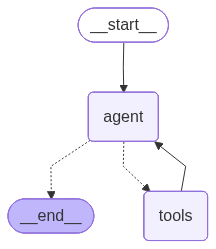

In [41]:
agent2 = create_agent(checkpointer2)
agent2

In [42]:
query = "What is the current weather in New Delhi?"
chat(agent2, query, "laxmikant")

[AGENT] called Tool get_weather with args ?
[AGENT/ToolMessage] Responding.

[AGENT/ToolMessage] Responding.
{"current_condition": [{"FeelsLikeC": "24", "FeelsLikeF": "75", "cloudcover": "0", "humidity": "41", "localObsDateTime": "2026-02-21 05:50 PM", "observation_time": "12:20 PM", "precipInches": "0.0", "precipMM": "0.0", "pressure": "1011", "pressureInches": "30", "temp_C": "25", "temp_F": "77", "uvIndex": "0", "visibility": "4", "visibilityMiles": "2", "weatherCode": "143", "weatherDesc": [{"value": "Haze"}], "weatherIconUrl": [{"value": ""}], "winddir16Point": "WNW", "winddirDegree": "293", "windspeedKmph": "10", "windspeedMiles": "6"}], "nearest_area": [{"areaName": [{"value": "New Delhi"}], "country": [{"value": "India"}], "latitude": "28.600", "longitude": "77.200", "population": "10928270", "region": [{"value": "Delhi"}], "weatherUrl": [{"value": ""}]}], "request": [{"query": "Lat 28.61 and Lon 77.22", "type": "LatLon"}], "weather": [{"astronomy": [{"moon_illumination": "14",

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01jdz3rxr6fnpt7frsvmhkkgez` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 11132, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

## Memory Persistence in PostgreSQL

In [43]:
import psycopg
os.environ["POSTGRESQL_URL"] = userdata.get('POSTGRESQL_URL')
conn = psycopg.connect(os.environ["POSTGRESQL_URL"], autocommit=True, prepare_threshold=0)

checkpointer3 = PostgresSaver(conn)

In [44]:
# setup for first time.
checkpointer3.setup()

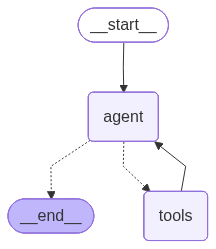

In [48]:
agent3 = create_agent(checkpointer3)
agent3

In [ ]:
query = "What is the current weather in New Delhi?"
chat(agent3, query, "laxmikant")